In [ ]:
!python main.py --csv /content/drive/MyDrive/malwave_dataset/dataset.csv --out /content/drive/MyDrive/malwave_dataset/

Traceback (most recent call last):
  File "/content/main.py", line 124, in <module>
    balance_bucket(df, 'T1_2014_2016'),
                   ^^
NameError: name 'df' is not defined


DEX extraction  : ok
DEX data size   : 3,965,688 bytes
Source SR       : 44100 Hz
Audio samples   : 1,982,844
Spectrogram shape: (256, 1404)  (freq_bins × time_bins)
Peaks extracted : 830


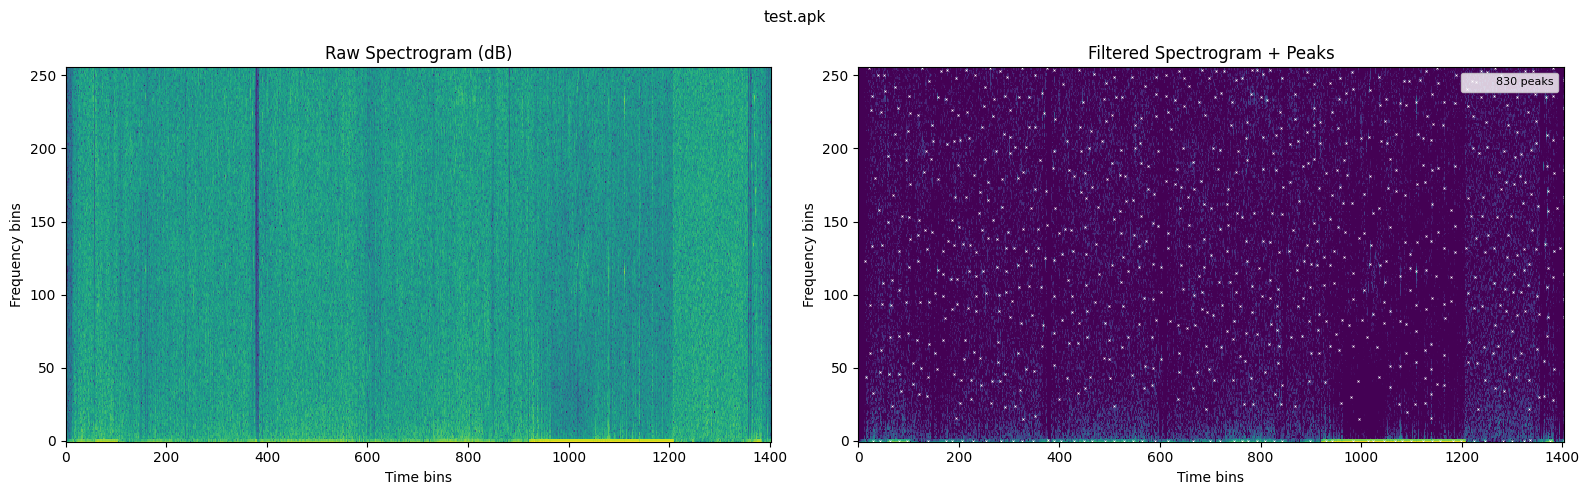


Sample peaks (first 5):
  f=0.0000  t=0.000538
  f=0.0000  t=0.000772
  f=0.0000  t=0.001131
  f=0.0000  t=0.001454
  f=0.0000  t=0.001723


In [ ]:
import numpy as np
import struct
import zipfile
import zlib
from scipy import signal
from scipy.signal import stft
from scipy.ndimage import grey_dilation
import matplotlib.pyplot as plt

# ─── STAGE 1: DEX EXTRACTION ──────────────────────────────────────────────────
def extract_dex_data_section(apk_path):
    try:
        with zipfile.ZipFile(apk_path, 'r') as z:
            names = z.namelist()

            # Single-DEX check
            dex_files = [n for n in names
                        if n.startswith("classes") and n.endswith(".dex")]
            if len(dex_files) != 1 or "classes.dex" not in dex_files:
                return None, "multi_dex"

            dex_bytes = z.read("classes.dex")

        # Verify DEX magic bytes
        magic = dex_bytes[:8]
        if not (magic.startswith(b'dex\n') and magic[7:8] == b'\x00'):
            return None, "invalid_magic"

        if len(dex_bytes) < 112:
            return None, "too_small"

        # Adler-32 checksum (bytes 12 onward, stored at offset 8)
        stored_checksum  = struct.unpack_from('<I', dex_bytes, 8)[0]
        computed_checksum = zlib.adler32(dex_bytes[12:]) & 0xFFFFFFFF
        if stored_checksum != computed_checksum:
            return None, "checksum_fail"

        # Parse data section offsets from DEX header
        data_size = struct.unpack_from('<I', dex_bytes, 104)[0]
        data_off  = struct.unpack_from('<I', dex_bytes, 108)[0]

        if data_off == 0 or data_size == 0:
            return None, "no_data_section"
        if data_off + data_size > len(dex_bytes):
            return None, "data_section_overflow"
        if data_size < 1024:
            return None, "data_section_too_small"

        return dex_bytes[data_off: data_off + data_size], "ok"

    except zipfile.BadZipFile:
        return None, "bad_zip"
    except Exception as e:
        return None, f"error_{str(e)[:40]}"


# ─── STAGE 2: SONIFICATION ────────────────────────────────────────────────────
def sonify(raw_bytes):
    """MalWave Equation 1: 16-bit little-endian PCM sonification."""
    if len(raw_bytes) % 2 != 0:
        raw_bytes = raw_bytes + b'\x00'
    arr = np.frombuffer(raw_bytes, dtype='<i2').astype(np.float32)
    return arr / 32768.0


# ─── STAGE 3: SPECTROGRAM ─────────────────────────────────────────────────────
def compute_spectrogram(audio, source_sr, target_sr=8000):
    """Downsample then STDFT per MalWave Table 2."""
    if source_sr != target_sr:
        n_target = int(len(audio) * target_sr / source_sr)
        audio = signal.resample(audio, n_target)

    if len(audio) < 512:
        return None

    _, _, Zxx = stft(
        audio,
        fs=target_sr,
        window='hamming',
        nperseg=512,
        noverlap=256,
        nfft=512,
        boundary=None,
        padded=False
    )

    # Magnitude, first 256 bins only (real signal symmetry)
    S_mag = np.abs(Zxx[:256, :])
    S_db  = 20 * np.log10(S_mag + 1e-10)
    return S_db


# ─── STAGE 4: FILTERING ───────────────────────────────────────────────────────
def apply_filtering(S_db):
    """MalWave Algorithm 2 filtering sequence."""
    S = S_db - S_db.mean()
    S = np.maximum(S, 0)

    b = np.array([1.0, -1.0])
    a = np.array([1.0, -0.98])
    S = signal.lfilter(b, a, S, axis=0)
    S = np.maximum(S, 0)
    return S


# ─── STAGE 5: PEAK EXTRACTION ─────────────────────────────────────────────────
def extract_peaks_from_spectrogram(S_filtered):
    """Morphological dilation peak detection."""
    struct_elem = np.ones((20, 20), dtype=np.float32)
    S_dilated   = grey_dilation(S_filtered,
                                footprint=struct_elem,
                                mode='nearest')

    peak_mask = (S_filtered == S_dilated) & (S_filtered > 0)
    f_idx, t_idx = np.where(peak_mask)

    if len(f_idx) == 0:
        return None, None

    f_norm = f_idx / 255.0
    t_norm = t_idx / 55727.0
    return f_norm.tolist(), t_norm.tolist()


# ─── FULL PIPELINE ────────────────────────────────────────────────────────────
def run_pipeline(apk_path):
    """Returns (peaks_f, peaks_t, status_str)."""
    raw, status = extract_dex_data_section(apk_path)
    if raw is None:
        return None, None, status

    source_sr = 44100 if len(raw) > 5646 else 8000
    audio     = sonify(raw)
    S_db      = compute_spectrogram(audio, source_sr=source_sr)

    if S_db is None:
        return None, None, "spectrogram_failed"

    S_filtered       = apply_filtering(S_db)
    peaks_f, peaks_t = extract_peaks_from_spectrogram(S_filtered)

    if peaks_f is None:
        return None, None, "no_peaks"

    return peaks_f, peaks_t, "ok"


# ─── SANITY CHECK + VISUALIZATION ────────────────────────────────────────────
def visualize_pipeline(apk_path):
    """Run pipeline and plot spectrogram with peaks overlaid."""

    # --- extraction diagnostics
    raw, status = extract_dex_data_section(apk_path)
    print(f"DEX extraction  : {status}")
    if raw is None:
        return

    print(f"DEX data size   : {len(raw):,} bytes")
    source_sr = 44100 if len(raw) > 5646 else 8000
    print(f"Source SR       : {source_sr} Hz")

    audio = sonify(raw)
    print(f"Audio samples   : {len(audio):,}")

    S_db = compute_spectrogram(audio, source_sr=source_sr)
    print(f"Spectrogram shape: {S_db.shape}  (freq_bins × time_bins)")

    S_filtered = apply_filtering(S_db)
    peaks_f, peaks_t = extract_peaks_from_spectrogram(S_filtered)

    n_peaks = len(peaks_f) if peaks_f else 0
    print(f"Peaks extracted : {n_peaks}")

    if n_peaks == 0:
        print("No peaks — cannot plot.")
        return

    # --- plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Raw spectrogram
    axes[0].imshow(S_db, aspect='auto', origin='lower',
                   cmap='viridis', interpolation='none')
    axes[0].set_title("Raw Spectrogram (dB)")
    axes[0].set_xlabel("Time bins")
    axes[0].set_ylabel("Frequency bins")

    # Filtered spectrogram + peaks
    axes[1].imshow(S_filtered, aspect='auto', origin='lower',
                   cmap='viridis', interpolation='none')

    # Convert normalised peaks back to bin indices for plotting
    f_bins = [round(f * 255) for f in peaks_f]
    t_bins = [round(t * 55727) for t in peaks_t]
    axes[1].scatter(t_bins, f_bins, c='white', s=2,
                    marker='x', linewidths=0.5, label=f'{n_peaks} peaks')
    axes[1].set_title("Filtered Spectrogram + Peaks")
    axes[1].set_xlabel("Time bins")
    axes[1].set_ylabel("Frequency bins")
    axes[1].legend(loc='upper right', fontsize=8)

    plt.suptitle(apk_path.split("/")[-1], fontsize=11)
    plt.tight_layout()
    plt.show()

    print(f"\nSample peaks (first 5):")
    for i in range(min(5, n_peaks)):
        print(f"  f={peaks_f[i]:.4f}  t={peaks_t[i]:.6f}")


# ─── RUN ──────────────────────────────────────────────────────────────────────
visualize_pipeline("./test.apk")

In [ ]:
# Kill whatever is running first, then run this cell
# Downloads ~2GB to Colab local disk. Takes 10-15 min.
# Do NOT save to Drive — local disk is much faster.

import subprocess, os

if not os.path.exists('/content/latest.csv.gz'):
    print("Downloading... (10-15 min)")
    result = subprocess.run(
        ["wget", "-q", "--show-progress",
         "https://androzoo.uni.lu/static/lists/latest.csv.gz",
         "-O", "/content/latest.csv.gz"],
        capture_output=False
    )
    print("Done." if result.returncode == 0 else f"Failed: {result.stderr}")
else:
    print("Already downloaded, skipping.")

print(f"File size: {os.path.getsize('/content/latest.csv.gz') / 1e9:.2f} GB")

Downloading... (10-15 min)
Done.
File size: 3.42 GB


In [ ]:
import gzip, csv, json, os
from collections import defaultdict
from google.colab import drive

drive.mount('/content/drive')

DRIVE_BASE       = "/content/drive/MyDrive/malwave_dataset"
SAMPLE_LIST_PATH = f"{DRIVE_BASE}/sample_list.json"
os.makedirs(DRIVE_BASE, exist_ok=True)

TARGET_PER_BUCKET    = 500
VT_MALWARE_THRESHOLD = 4

BUCKETS = [
    ("T1_2014_2016", 2014, 2016),
    ("T2_2017_2018", 2017, 2018),
    ("T3_2019_2020", 2019, 2020),
    ("T4_2021_2023", 2021, 2023),
]

TOTAL_NEEDED = len(BUCKETS) * 2 * TARGET_PER_BUCKET

def get_bucket(date_str):
    try:
        year = int(date_str.strip()[:4])
        for name, y0, y1 in BUCKETS:
            if y0 <= year <= y1:
                return name
    except Exception:
        pass
    return None

def get_label(vt_str):
    try:
        vt = int(vt_str)
        if vt >= VT_MALWARE_THRESHOLD:
            return "malware"
        if vt == 0:
            return "benign"
    except Exception:
        pass
    return None

# ─────────────────────────────────────────────────────────────────────────────
collected = defaultdict(list)
counts    = defaultdict(int)

def all_full():
    return sum(counts.values()) >= TOTAL_NEEDED

print("Parsing CSV...")

with gzip.open('/content/latest.csv.gz', 'rt',
               encoding='utf-8', errors='replace') as gz:
    reader = csv.DictReader(gz)

    for i, row in enumerate(reader):

        if i % 100_000 == 0:
            print(f"  Row {i:,} | Collected {sum(counts.values())}/{TOTAL_NEEDED}")

        sha256   = row.get('sha256', '').strip().upper()
        vt_str   = row.get('vt_detection', '').strip()
        dex_date = row.get('dex_date', '').strip()
        pkg_name = row.get('pkg_name', '').strip()
        markets  = row.get('markets', '').strip()

        try:
            dex_size = int(row.get('dex_size', '0').strip())
        except Exception:
            continue

        bucket = get_bucket(dex_date)
        label  = get_label(vt_str)

        if not sha256 or len(sha256) != 64:
            continue
        if bucket is None or label is None:
            continue
        if dex_size < 1024 or dex_size > 52428800:
            continue

        key = (bucket, label)
        if counts[key] >= TARGET_PER_BUCKET:
            continue

        collected[key].append({
            "sha256":       sha256,
            "pkg_name":     pkg_name,
            "vt_detection": int(vt_str) if vt_str.lstrip('-').isdigit() else -1,
            "dex_size":     dex_size,
            "date_bucket":  bucket,
            "label":        label,
            "date":         dex_date,
            "markets":      markets,
        })
        counts[key] += 1

        if all_full():
            print(f"\n✓ All slots filled at row {i:,}")
            break

# ─── Summary ─────────────────────────────────────────────────────────────────
print("\n─── Summary ──────────────────────────────────────────")
all_samples = []
for name, _, _ in BUCKETS:
    for label in ["malware", "benign"]:
        key = (name, label)
        n   = counts[key]
        ok  = "✓" if n >= TARGET_PER_BUCKET else f"⚠ only {n}"
        print(f"  {ok:12s}  {name} | {label}")
        all_samples.extend(collected[key])

print(f"\n  TOTAL : {len(all_samples)} samples")

# ─── Save ────────────────────────────────────────────────────────────────────
print(f"\nSaving to Drive...")
with open(SAMPLE_LIST_PATH, 'w') as f:
    json.dump(all_samples, f)

print(f"✓ Saved → {SAMPLE_LIST_PATH}")
print(f"  Size  : {os.path.getsize(SAMPLE_LIST_PATH)/1e6:.1f} MB")

# ─── Cleanup ─────────────────────────────────────────────────────────────────
os.remove('/content/latest.csv.gz')
print("✓ Local CSV removed")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parsing CSV...
  Row 0 | Collected 0/4000
  Row 100,000 | Collected 3661/4000
  Row 200,000 | Collected 3836/4000
  Row 300,000 | Collected 3985/4000

✓ All slots filled at row 307,949

─── Summary ──────────────────────────────────────────
  ✓             T1_2014_2016 | malware
  ✓             T1_2014_2016 | benign
  ✓             T2_2017_2018 | malware
  ✓             T2_2017_2018 | benign
  ✓             T3_2019_2020 | malware
  ✓             T3_2019_2020 | benign
  ✓             T4_2021_2023 | malware
  ✓             T4_2021_2023 | benign

  TOTAL : 4000 samples

Saving to Drive...
✓ Saved → /content/drive/MyDrive/malwave_dataset/sample_list.json
  Size  : 1.1 MB
✓ Local CSV removed


In [ ]:
# ─── PHASE 2: DOWNLOAD + PIPELINE + CSV ───────────────────────────────────────
# Loads sample_list.json from Drive, processes each APK:
#   download → extract DEX → sonify → STDFT → peaks → append to CSV → delete APK
#
# Features:
#   - Checkpoint: never reprocesses a completed SHA256
#   - Batch flush: writes to Drive every 50 samples (not per-APK)
#   - Failure logging: records why each APK was skipped
#   - Progress bar via tqdm
# ─────────────────────────────────────────────────────────────────────────────

import os
import csv
import json
import time
import requests
import numpy as np
import struct
import zipfile
import zlib
from scipy import signal
from scipy.signal import stft
from scipy.ndimage import grey_dilation
from google.colab import drive
from tqdm.notebook import tqdm

drive.mount('/content/drive')

# ─── CONFIG ───────────────────────────────────────────────────────────────────
API_KEY          = "773e91551cc8b02bc0eec2afa51344547f63b3220926a77fa478badc2dc60a3f"
DRIVE_BASE       = "/content/drive/MyDrive/malwave_dataset"
SAMPLE_LIST_PATH = f"{DRIVE_BASE}/sample_list.json"
OUTPUT_CSV       = f"{DRIVE_BASE}/dataset.csv"
CHECKPOINT_FILE  = f"{DRIVE_BASE}/checkpoint.txt"
FAILURE_LOG      = f"{DRIVE_BASE}/failures.csv"
TEMP_DIR         = "/content/tmp_apk"
BATCH_SIZE       = 50

os.makedirs(DRIVE_BASE, exist_ok=True)
os.makedirs(TEMP_DIR,   exist_ok=True)

CSV_HEADER      = ["sha256", "pkg_name", "vt_detection", "dex_size",
                   "date", "date_bucket", "label", "n_peaks",
                   "peaks_f", "peaks_t"]
FAIL_HEADER     = ["sha256", "date_bucket", "label", "reason"]

# ─── CHECKPOINT ───────────────────────────────────────────────────────────────
def load_checkpoint():
    if not os.path.exists(CHECKPOINT_FILE):
        return set()
    with open(CHECKPOINT_FILE) as f:
        return set(l.strip() for l in f if l.strip())

def mark_done(sha256):
    with open(CHECKPOINT_FILE, 'a') as f:
        f.write(sha256 + '\n')

# ─── CSV HELPERS ──────────────────────────────────────────────────────────────
def flush_buffer(buffer):
    if not buffer:
        return
    file_exists = os.path.exists(OUTPUT_CSV)
    with open(OUTPUT_CSV, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=CSV_HEADER)
        if not file_exists:
            w.writeheader()
        w.writerows(buffer)

def log_failure(sha256, meta, reason):
    file_exists = os.path.exists(FAILURE_LOG)
    with open(FAILURE_LOG, 'a', newline='') as f:
        w = csv.DictWriter(f, fieldnames=FAIL_HEADER)
        if not file_exists:
            w.writeheader()
        w.writerow({
            "sha256":       sha256,
            "date_bucket":  meta.get("date_bucket", ""),
            "label":        meta.get("label", ""),
            "reason":       reason
        })

# ─── DOWNLOAD ─────────────────────────────────────────────────────────────────
def download_apk(sha256, dest_path, retries=3):
    url = (f"https://androzoo.uni.lu/api/download"
           f"?apikey={API_KEY}&sha256={sha256}")
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=90, stream=True)
            if r.status_code == 200:
                with open(dest_path, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=16384):
                        f.write(chunk)
                return True
            elif r.status_code == 404:
                return False   # APK not available, don't retry
            elif r.status_code == 429:
                time.sleep(60) # Rate limited, wait 1 min
        except requests.exceptions.Timeout:
            time.sleep(2 ** attempt)
        except Exception:
            time.sleep(2 ** attempt)
    return False

# ─── PIPELINE (same as Phase 1 sanity check cell) ─────────────────────────────
def extract_dex_data_section(apk_path):
    try:
        with zipfile.ZipFile(apk_path, 'r') as z:
            names     = z.namelist()
            dex_files = [n for n in names
                         if n.startswith("classes") and n.endswith(".dex")]
            if len(dex_files) != 1 or "classes.dex" not in dex_files:
                return None, "multi_dex"
            dex_bytes = z.read("classes.dex")

        if not dex_bytes[:4] == b'dex\n':
            return None, "invalid_magic"
        if len(dex_bytes) < 112:
            return None, "too_small"

        stored   = struct.unpack_from('<I', dex_bytes, 8)[0]
        computed = zlib.adler32(dex_bytes[12:]) & 0xFFFFFFFF
        if stored != computed:
            return None, "checksum_fail"

        data_size = struct.unpack_from('<I', dex_bytes, 104)[0]
        data_off  = struct.unpack_from('<I', dex_bytes, 108)[0]

        if data_off == 0 or data_size == 0:
            return None, "no_data_section"
        if data_off + data_size > len(dex_bytes):
            return None, "overflow"
        if data_size < 1024:
            return None, "data_too_small"

        return dex_bytes[data_off: data_off + data_size], "ok"

    except zipfile.BadZipFile:
        return None, "bad_zip"
    except Exception as e:
        return None, f"error_{str(e)[:30]}"

def sonify(raw_bytes):
    if len(raw_bytes) % 2 != 0:
        raw_bytes = raw_bytes + b'\x00'
    arr = np.frombuffer(raw_bytes, dtype='<i2').astype(np.float32)
    return arr / 32768.0

def compute_spectrogram(audio, source_sr, target_sr=8000):
    if source_sr != target_sr:
        n_target = int(len(audio) * target_sr / source_sr)
        audio    = signal.resample(audio, n_target)
    if len(audio) < 512:
        return None
    _, _, Zxx = stft(audio, fs=target_sr, window='hamming',
                     nperseg=512, noverlap=256, nfft=512,
                     boundary=None, padded=False)
    S_mag = np.abs(Zxx[:256, :])
    return 20 * np.log10(S_mag + 1e-10)

def apply_filtering(S_db):
    S = S_db - S_db.mean()
    S = np.maximum(S, 0)
    S = signal.lfilter([1., -1.], [1., -0.98], S, axis=0)
    return np.maximum(S, 0)

def extract_peaks(S_filtered):
    S_dilated = grey_dilation(S_filtered,
                              footprint=np.ones((20,20), dtype=np.float32),
                              mode='nearest')
    mask = (S_filtered == S_dilated) & (S_filtered > 0)
    f_idx, t_idx = np.where(mask)
    if len(f_idx) == 0:
        return None, None
    return (f_idx / 255.0).tolist(), (t_idx / 55727.0).tolist()

def run_pipeline(apk_path):
    raw, status = extract_dex_data_section(apk_path)
    if raw is None:
        return None, None, status

    source_sr  = 44100 if len(raw) > 5646 else 8000
    audio      = sonify(raw)
    S_db       = compute_spectrogram(audio, source_sr)
    if S_db is None:
        return None, None, "spectrogram_failed"

    S_filtered = apply_filtering(S_db)
    peaks_f, peaks_t = extract_peaks(S_filtered)
    if peaks_f is None:
        return None, None, "no_peaks"

    return peaks_f, peaks_t, "ok"

# ─── MAIN LOOP ────────────────────────────────────────────────────────────────
def run_collection():
    # Load sample list
    with open(SAMPLE_LIST_PATH) as f:
        sample_list = json.load(f)

    # Skip already processed
    done    = load_checkpoint()
    pending = [s for s in sample_list if s['sha256'] not in done]

    print(f"Total samples   : {len(sample_list)}")
    print(f"Already done    : {len(done)}")
    print(f"Remaining       : {len(pending)}\n")

    # Counters for live stats
    stats = {"ok": 0, "skipped": 0, "failed_dl": 0}
    buffer = []

    pbar = tqdm(pending, desc="Processing", unit="apk")

    for meta in pbar:
        sha256   = meta['sha256']
        apk_path = os.path.join(TEMP_DIR, sha256 + ".apk")

        # ── Download ──────────────────────────────────────────────────────────
        dl_ok = download_apk(sha256, apk_path)
        if not dl_ok:
            log_failure(sha256, meta, "download_failed")
            mark_done(sha256)
            stats["failed_dl"] += 1
            pbar.set_postfix(stats)
            continue

        # ── Pipeline ──────────────────────────────────────────────────────────
        try:
            peaks_f, peaks_t, status = run_pipeline(apk_path)
        except Exception as e:
            status   = f"exception_{str(e)[:30]}"
            peaks_f  = None
            peaks_t  = None
        finally:
            # Always delete APK immediately
            if os.path.exists(apk_path):
                os.remove(apk_path)

        # ── Record result ─────────────────────────────────────────────────────
        if peaks_f is not None:
            buffer.append({
                "sha256":       sha256,
                "pkg_name":     meta.get("pkg_name", ""),
                "vt_detection": meta.get("vt_detection", -1),
                "dex_size":     meta.get("dex_size", -1),
                "date":         meta.get("date", ""),
                "date_bucket":  meta.get("date_bucket", ""),
                "label":        meta.get("label", ""),
                "n_peaks":      len(peaks_f),
                "peaks_f":      json.dumps(peaks_f),
                "peaks_t":      json.dumps(peaks_t),
            })
            stats["ok"] += 1
        else:
            log_failure(sha256, meta, status)
            stats["skipped"] += 1

        mark_done(sha256)
        pbar.set_postfix(stats)

        # ── Batch flush to Drive ───────────────────────────────────────────────
        if len(buffer) >= BATCH_SIZE:
            flush_buffer(buffer)
            buffer.clear()

    # Final flush
    flush_buffer(buffer)

    # ── Final summary ─────────────────────────────────────────────────────────
    print("\n─── Final Summary ────────────────────────────────────")
    print(f"  Successful      : {stats['ok']}")
    print(f"  Skipped/filtered: {stats['skipped']}")
    print(f"  Download failed : {stats['failed_dl']}")
    print(f"\n  Dataset CSV     : {OUTPUT_CSV}")
    print(f"  Failure log     : {FAILURE_LOG}")
    print(f"  Checkpoint      : {CHECKPOINT_FILE}")

run_collection()

Total samples: 2500
Max peaks (95th percentile): 1255

Training RandomForest on T1...

Training GradientBoosting on T1...

Experiment 1 Results:
              Model TestBucket       F1+  Accuracy   ROC-AUC
0      RandomForest         T1  1.000000  1.000000  1.000000
1      RandomForest         T2  0.789651  0.788222  0.829104
2      RandomForest         T3  0.939426  0.914414  0.938851
3  GradientBoosting         T1  0.933333  0.933754  0.984033
4  GradientBoosting         T2  0.775056  0.771234  0.827416
5  GradientBoosting         T3  0.917927  0.885886  0.955232


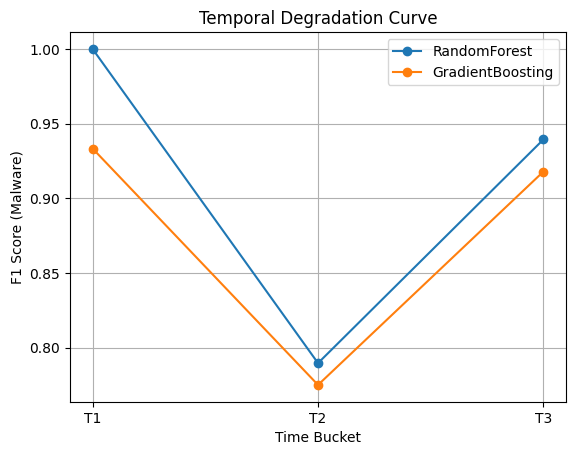


Experiment 2 Results:
              Model TrainBuckets TestBucket       F1+  Accuracy   ROC-AUC
0      RandomForest           T1         T2  0.789651  0.788222  0.829104
1      RandomForest        T1+T2         T3  0.949733  0.929429  0.959336
2  GradientBoosting           T1         T2  0.775056  0.771234  0.827416
3  GradientBoosting        T1+T2         T3  0.941799  0.917417  0.961284

Experiment 3 Matrix:
               Model Train Test       F1+
0       RandomForest    T1   T1  1.000000
1       RandomForest    T1   T2  0.789651
2       RandomForest    T1   T3  0.939426
3   GradientBoosting    T1   T1  0.933333
4   GradientBoosting    T1   T2  0.775056
5   GradientBoosting    T1   T3  0.917927
6       RandomForest    T2   T1  0.530726
7       RandomForest    T2   T2  1.000000
8       RandomForest    T2   T3  0.947826
9   GradientBoosting    T2   T1  0.517906
10  GradientBoosting    T2   T2  0.990496
11  GradientBoosting    T2   T3  0.944745
12      RandomForest    T3   T1  0.4306

100%|██████████| 666/666 [00:54<00:00, 12.13it/s]



FAI Computed.


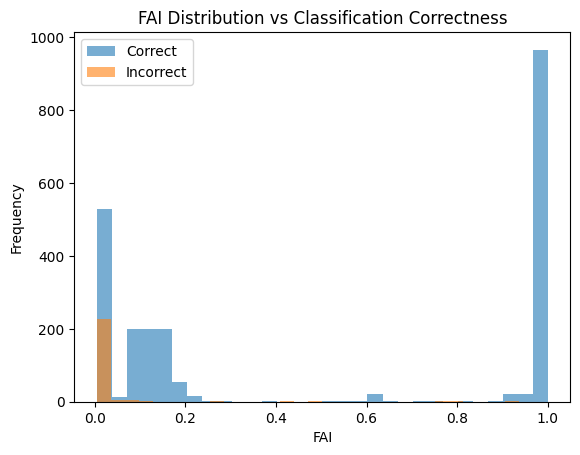


ALL EXPERIMENTS COMPLETED & SAVED.


In [28]:
# =========================
# MALWAVE TEMPORAL DRIFT PIPELINE + FAI
# =========================

import pandas as pd
import numpy as np
import json
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
from collections import defaultdict

# -------------------------
# 1. LOAD DATASET
# -------------------------
df = pd.read_csv('/content/drive/MyDrive/malwave_dataset/dataset.csv')
df['label_num'] = df['label'].map({
    'benign': 0,
    'malware': 1
})

# Parse JSON safely
df['peaks_f'] = df['peaks_f'].apply(lambda x: json.loads(x) if isinstance(x, str) else [])
df['peaks_t'] = df['peaks_t'].apply(lambda x: json.loads(x) if isinstance(x, str) else [])

# Remove empty samples
df = df[df['n_peaks'] > 0].reset_index(drop=True)

print("Total samples:", len(df))

# -------------------------
# 2. FEATURE ENGINEERING
# -------------------------

# Use percentile cap instead of max (prevents memory explosion)
max_peaks = int(np.percentile(df['n_peaks'], 95))
print("Max peaks (95th percentile):", max_peaks)

def build_feature(row):
    f = row['peaks_f'][:max_peaks]
    t = row['peaks_t'][:max_peaks]

    # padding
    f += [0] * (max_peaks - len(f))
    t += [0] * (max_peaks - len(t))

    return np.array(f + t)

df['features'] = df.apply(build_feature, axis=1)

# Convert to matrix
X = np.stack(df['features'].values)
y = df['label_num'].values
df['date_bucket_clean'] = df['date_bucket'].map({
    'T1_2014_2016': 'T1',
    'T2_2017_2018': 'T2',
    'T3_2019_2020': 'T3',
    'T4_2021_2023': 'T4'
})
# -------------------------
# 3. TEMPORAL SPLITS
# -------------------------
buckets = ['T1','T2','T3','T4']
splits = {b: df[df['date_bucket_clean'] == b] for b in buckets}

train_T1 = splits['T1']

# -------------------------
# 4. MODEL SETUP
# -------------------------
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

models = {
    "RandomForest": rf,
    "GradientBoosting": gb
}

# -------------------------
# 5. METRIC FUNCTION
# -------------------------
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else preds

    return {
        "F1+": f1_score(y_test, preds),
        "Accuracy": accuracy_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs) if len(np.unique(y_test))>1 else np.nan
    }

# -------------------------
# 6. EXPERIMENT 1: TEMPORAL DEGRADATION
# -------------------------
results_exp1 = []

for name, model in models.items():
    print(f"\nTraining {name} on T1...")
    model.fit(np.stack(train_T1['features']), train_T1['label_num'])

    for b in buckets:
        if len(splits[b]) == 0:
            continue

        X_test = np.stack(splits[b]['features'])
        y_test = splits[b]['label_num'].values

        metrics = evaluate(model, X_test, y_test)

        results_exp1.append({
            "Model": name,
            "TestBucket": b,
            **metrics
        })

df_exp1 = pd.DataFrame(results_exp1)
print("\nExperiment 1 Results:")
print(df_exp1)

# -------------------------
# 7. PLOT DEGRADATION CURVE
# -------------------------
plt.figure()
for name in df_exp1['Model'].unique():
    subset = df_exp1[df_exp1['Model'] == name]
    plt.plot(subset['TestBucket'], subset['F1+'], marker='o', label=name)

plt.title("Temporal Degradation Curve")
plt.xlabel("Time Bucket")
plt.ylabel("F1 Score (Malware)")
plt.legend()
plt.grid()
plt.show()

# -------------------------
# 8. EXPERIMENT 2: ROLLING RETRAINING
# -------------------------
results_exp2 = []

train_sets = [
    ['T1'],
    ['T1','T2'],
    ['T1','T2','T3']
]

test_targets = ['T2','T3','T4']

for name, model in models.items():
    for train_buckets, test_bucket in zip(train_sets, test_targets):

        train_df = df[df['date_bucket_clean'].isin(train_buckets)]
        test_df = splits[test_bucket]

        if len(test_df) == 0:
            continue

        model.fit(np.stack(train_df['features']), train_df['label_num'])

        metrics = evaluate(
            model,
            np.stack(test_df['features']),
            test_df['label_num'].values
        )

        results_exp2.append({
            "Model": name,
            "TrainBuckets": "+".join(train_buckets),
            "TestBucket": test_bucket,
            **metrics
        })

df_exp2 = pd.DataFrame(results_exp2)
print("\nExperiment 2 Results:")
print(df_exp2)

# -------------------------
# 9. EXPERIMENT 3: CROSS-GENERALIZATION MATRIX
# -------------------------
matrix_results = []

for train_b in buckets:
    if len(splits[train_b]) == 0:
        continue

    for name, model in models.items():
        model.fit(np.stack(splits[train_b]['features']), splits[train_b]['label_num'])

        for test_b in buckets:
            if len(splits[test_b]) == 0:
                continue

            metrics = evaluate(
                model,
                np.stack(splits[test_b]['features']),
                splits[test_b]['label_num'].values
            )

            matrix_results.append({
                "Model": name,
                "Train": train_b,
                "Test": test_b,
                "F1+": metrics["F1+"]
            })

df_matrix = pd.DataFrame(matrix_results)
print("\nExperiment 3 Matrix:")
print(df_matrix)

# -------------------------
# 10. FAI IMPLEMENTATION (NOVELTY)
# -------------------------

print("\nComputing FAI (this may take time)...")

# Convert peaks to integer sets (denormalize)
def to_set(row):
    return set(zip(
        (np.array(row['peaks_f']) * 255).astype(int),
        (np.array(row['peaks_t']) * 55727).astype(int)
    ))

train_sets_peaks = [to_set(r) for _, r in train_T1.iterrows()]

fai_scores = []
correct_flags = []
buckets_list = []

model = rf
model.fit(np.stack(train_T1['features']), train_T1['label_num'])

for b in buckets:
    if len(splits[b]) == 0:
        continue

    for _, row in tqdm(splits[b].iterrows(), total=len(splits[b])):

        test_set = to_set(row)

        max_jaccard = 0
        for train_set in train_sets_peaks:
            if len(test_set) == 0 or len(train_set) == 0:
                continue

            inter = len(test_set & train_set)
            union = len(test_set | train_set)

            if union > 0:
                max_jaccard = max(max_jaccard, inter / union)

        fai_scores.append(max_jaccard)

        pred = model.predict(row['features'].reshape(1,-1))[0]
        correct_flags.append(int(pred == row['label_num']))
        buckets_list.append(b)

df_fai = pd.DataFrame({
    "FAI": fai_scores,
    "Correct": correct_flags,
    "Bucket": buckets_list
})

print("\nFAI Computed.")

# -------------------------
# 11. FAI PLOT (KEY NOVEL FIGURE)
# -------------------------
plt.figure()

correct = df_fai[df_fai['Correct'] == 1]['FAI']
incorrect = df_fai[df_fai['Correct'] == 0]['FAI']

plt.hist(correct, bins=30, alpha=0.6, label="Correct")
plt.hist(incorrect, bins=30, alpha=0.6, label="Incorrect")

plt.title("FAI Distribution vs Classification Correctness")
plt.xlabel("FAI")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# -------------------------
# SAVE RESULTS
# -------------------------
df_exp1.to_csv('/content/drive/MyDrive/exp1_results.csv', index=False)
df_exp2.to_csv('/content/drive/MyDrive/exp2_results.csv', index=False)
df_matrix.to_csv('/content/drive/MyDrive/exp3_matrix.csv', index=False)
df_fai.to_csv('/content/drive/MyDrive/fai_results.csv', index=False)

print("\nALL EXPERIMENTS COMPLETED & SAVED.")

In [19]:
print(df['date_bucket'].value_counts())

date_bucket
T1_2014_2016    951
T2_2017_2018    883
T3_2019_2020    666
Name: count, dtype: int64


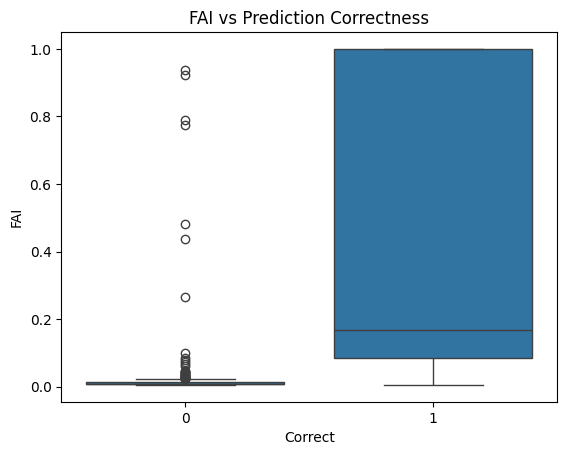

In [29]:
import seaborn as sns

sns.boxplot(x="Correct", y="FAI", data=df_fai)
plt.title("FAI vs Prediction Correctness")
plt.show()

In [31]:
threshold = 0.05  # tune later

df_fai['Flagged'] = df_fai['FAI'] < threshold

error_cases = df_fai[df_fai['Correct'] == 0]
caught = error_cases['Flagged'].sum()

print("Errors caught by FAI:", caught / len(error_cases))

Errors caught by FAI: 0.9467213114754098


In [33]:
time_map = {'T1':2015, 'T2':2017.5, 'T3':2019.5}

df_exp1['Year'] = df_exp1['TestBucket'].map(time_map)

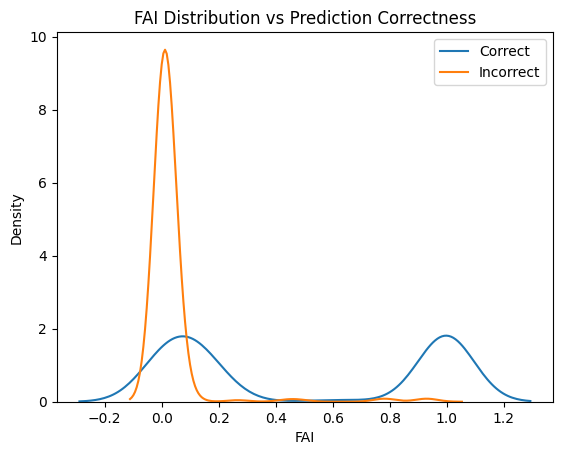

In [34]:
import seaborn as sns

sns.kdeplot(data=df_fai[df_fai['Correct']==1], x="FAI", label="Correct")
sns.kdeplot(data=df_fai[df_fai['Correct']==0], x="FAI", label="Incorrect")

plt.title("FAI Distribution vs Prediction Correctness")
plt.legend()
plt.show()

In [ ]:
"""
MalWave Temporal Drift Analysis — Phase 3 & 4
==============================================
Extends MalWave (Vasilellis et al., IJIS 2025) with a temporal degradation
analysis framework and the Fingerprint Age Index (FAI) metric.

Pipeline
--------
1. Load dataset.csv from Drive (or local path)
2. Parse + validate features, stratify by date_bucket
3. EDA plots  (dataset composition, peak distributions, bucket counts)
4. Experiment 1 — Train T1, test T2/T3/T4 → degradation curve
5. Experiment 2 — Rolling window retraining
6. Experiment 3 — Per-bucket cross-generalisation matrix
7. FAI computation and validation plots
8. Summary table (paper-ready)

Usage
-----
    python malwave_phase3_ml.py --csv /path/to/dataset.csv --out ./results/
"""

import argparse
import json
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot style — publication-quality ──────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "legend.framealpha": 0.9,
    "lines.linewidth": 2,
})

BUCKET_ORDER  = ["T1_2014_2016", "T2_2017_2018", "T3_2019_2020"]
BUCKET_LABELS = ["T1\n(2014–16)", "T2\n(2017–18)", "T3\n(2019–20)"]
BUCKET_COLOR  = {
    "T1_2014_2016": "#2166ac",
    "T2_2017_2018": "#4dac26",
    "T3_2019_2020": "#d6604d",
    "T4_2021_2023": "#8B008B",
}
MAX_PEAKS = 5000   # hard cap for padding (paper uses 55727 t-bins, we cap here)


# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_dataset(csv_path: str) -> pd.DataFrame:
    """Load dataset.csv produced by the collection pipeline."""
    print(f"[INFO] Loading dataset from: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"[INFO] Raw rows: {len(df)}")

    # Parse JSON peak arrays
    def parse_peaks(s):
        try:
            arr = json.loads(s)
            return np.array(arr, dtype=np.float32)
        except Exception:
            return np.array([], dtype=np.float32)

    df["peaks_f_arr"] = df["peaks_f"].apply(parse_peaks)
    df["peaks_t_arr"] = df["peaks_t"].apply(parse_peaks)

    # Compute n_peaks from arrays (ground truth)
    df["n_peaks_actual"] = df["peaks_f_arr"].apply(len)

    # Drop rows with no peaks
    before = len(df)
    df = df[df["n_peaks_actual"] > 0].copy()
    print(f"[INFO] Dropped {before - len(df)} zero-peak rows → {len(df)} remaining")

    # Enforce bucket ordering
    df["date_bucket"] = pd.Categorical(df["date_bucket"],
                                        categories=BUCKET_ORDER, ordered=True)
    df = df.dropna(subset=["date_bucket"])
    df["label_int"] = (df["label"] == "malware").astype(int)

    print(f"[INFO] Final dataset: {len(df)} samples")
    print(df.groupby(["date_bucket", "label"]).size().unstack(fill_value=0))
    return df


# ══════════════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════

def build_feature_matrix(df: pd.DataFrame, max_peaks: int = MAX_PEAKS) -> np.ndarray:
    """
    Flatten (f_norm, t_norm) peak pairs into a fixed-length feature vector.
    Interleaved: [f0, t0, f1, t1, ..., f_{max_peaks-1}, t_{max_peaks-1}]
    Truncated / zero-padded to 2*max_peaks dimensions.
    Matches MalWave Algorithm 3 preprocessing.
    """
    feat_dim = 2 * max_peaks
    X = np.zeros((len(df), feat_dim), dtype=np.float32)
    for i, (_, row) in enumerate(df.iterrows()):
        f = row["peaks_f_arr"]
        t = row["peaks_t_arr"]
        n = min(len(f), max_peaks)
        if n > 0:
            X[i, 0::2][:n] = f[:n]   # frequency slots
            X[i, 1::2][:n] = t[:n]   # time slots
    return X


def adaptive_max_peaks(df: pd.DataFrame, percentile: float = 95) -> int:
    """Choose max_peaks from the dataset distribution to avoid extreme padding."""
    p = int(np.percentile(df["n_peaks_actual"], percentile))
    p = max(p, 50)
    print(f"[INFO] Adaptive max_peaks (P{percentile:.0f}): {p}")
    return p


# ══════════════════════════════════════════════════════════════════════════════
# 3. EDA / DATASET DOCUMENTATION PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def plot_dataset_composition(df: pd.DataFrame, out_dir: str):
    """Figure: stacked bar — sample counts per bucket × label."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left — stacked bar
    ax = axes[0]
    buckets = [b for b in BUCKET_ORDER if b in df["date_bucket"].cat.categories]
    mal_counts = [len(df[(df["date_bucket"] == b) & (df["label"] == "malware")]) for b in buckets]
    ben_counts = [len(df[(df["date_bucket"] == b) & (df["label"] == "benign")])  for b in buckets]
    x = np.arange(len(buckets))
    bars_m = ax.bar(x, mal_counts, color="#d6604d", label="Malware", alpha=0.9)
    bars_b = ax.bar(x, ben_counts, bottom=mal_counts, color="#4393c3",
                    label="Benign", alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels([BUCKET_LABELS[BUCKET_ORDER.index(b)] for b in buckets])
    ax.set_ylabel("Sample Count")
    ax.set_title("Dataset Composition by Temporal Bucket")
    ax.legend()
    for bar, v in zip(bars_m, mal_counts):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v/2, str(v),
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    for bar, m, b in zip(bars_b, mal_counts, ben_counts):
        if b > 0:
            ax.text(bar.get_x() + bar.get_width()/2, m + b/2, str(b),
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    # Right — pie breakdown
    ax2 = axes[1]
    total_mal = len(df[df["label"] == "malware"])
    total_ben = len(df[df["label"] == "benign"])
    ax2.pie([total_mal, total_ben],
            labels=[f"Malware\n({total_mal})", f"Benign\n({total_ben})"],
            colors=["#d6604d", "#4393c3"],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
    ax2.set_title("Overall Class Balance")

    fig.suptitle("Figure 1 — Temporally Stratified Dataset Overview", fontweight='bold')
    fig.tight_layout()
    path = os.path.join(out_dir, "fig1_dataset_composition.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")


def plot_peak_distributions(df: pd.DataFrame, out_dir: str):
    """Figure: peak count distributions per bucket (violin + box)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left — violin by bucket
    ax = axes[0]
    data_by_bucket = [
        df[df["date_bucket"] == b]["n_peaks_actual"].values
        for b in BUCKET_ORDER if b in df["date_bucket"].cat.categories
    ]
    valid_buckets = [b for b in BUCKET_ORDER if b in df["date_bucket"].cat.categories]
    parts = ax.violinplot(data_by_bucket, positions=range(len(data_by_bucket)),
                          showmedians=True, showextrema=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(list(BUCKET_COLOR.values())[i % len(BUCKET_COLOR)])
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(valid_buckets)))
    ax.set_xticklabels([BUCKET_LABELS[BUCKET_ORDER.index(b)] for b in valid_buckets])
    ax.set_ylabel("Number of Peaks per Sample")
    ax.set_title("Peak Count Distribution by Temporal Bucket")

    # Right — histogram overall
    ax2 = axes[1]
    cap = np.percentile(df["n_peaks_actual"], 99)
    clipped = df["n_peaks_actual"].clip(upper=cap)
    for b in valid_buckets:
        sub = clipped[df["date_bucket"] == b]
        ax2.hist(sub, bins=40, alpha=0.55, label=b.replace("_", " "),
                 color=BUCKET_COLOR[b], density=True)
    ax2.set_xlabel("Peak Count (clipped at P99)")
    ax2.set_ylabel("Density")
    ax2.set_title("Peak Count Histogram (by Bucket)")
    ax2.legend(fontsize=9)

    fig.suptitle("Figure 2 — Audio Fingerprint Peak Distributions", fontweight='bold')
    fig.tight_layout()
    path = os.path.join(out_dir, "fig2_peak_distributions.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")


def plot_peak_scatter(df: pd.DataFrame, out_dir: str, n_samples: int = 6):
    """Figure: scatter of (f_norm, t_norm) peaks for a few samples per class."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    parts = []
    for lbl in ["malware", "benign"]:
        sub = df[df["label"] == lbl]
        parts.append(sub.sample(min(3, len(sub)), random_state=SEED))
    subset = pd.concat(parts, ignore_index=True).head(n_samples)

    for i, (_, row) in enumerate(subset.iterrows()):
        ax = axes[i]
        f = row["peaks_f_arr"]
        t = row["peaks_t_arr"]
        color = "#d6604d" if row["label"] == "malware" else "#4393c3"
        ax.scatter(t, f, s=3, alpha=0.5, color=color)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("t_norm"); ax.set_ylabel("f_norm")
        label_str = row["label"].capitalize()
        ax.set_title(f"{label_str} | {row['date_bucket'].replace('_',' ')}\n"
                     f"n_peaks={len(f)}", fontsize=9)
    fig.suptitle("Figure 3 — Representative Audio Fingerprint Scatterplots", fontweight='bold')
    fig.tight_layout()
    path = os.path.join(out_dir, "fig3_peak_scatters.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")


# ══════════════════════════════════════════════════════════════════════════════
# 4. METRIC HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def compute_metrics(y_true, y_pred, y_prob=None):
    """Standard malware detection metrics matching MalWave Table 8."""
    m = {}
    m["F1+"]      = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    m["F1-"]      = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
    m["Precision"]= precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    m["Recall"]   = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    m["Accuracy"] = accuracy_score(y_true, y_pred)
    m["MacroF1"]  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    if y_prob is not None:
        try:
            m["ROC_AUC"] = roc_auc_score(y_true, y_prob)
            m["AP"]      = average_precision_score(y_true, y_prob)
        except Exception:
            m["ROC_AUC"] = np.nan
            m["AP"]      = np.nan
    return m


def get_model():
    """MalWave best model — Random Forest, matched hyperparameters."""
    return RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        n_jobs=-1,
        random_state=SEED,
        class_weight="balanced",
    )


# ══════════════════════════════════════════════════════════════════════════════
# 5. EXPERIMENT 1 — TEMPORAL DEGRADATION CURVE
# ══════════════════════════════════════════════════════════════════════════════

def experiment1_degradation(df: pd.DataFrame, X: np.ndarray, out_dir: str) -> pd.DataFrame:
    """
    Train on T1 only. Test on T1 (in-distribution), T2, T3.
    Reports F1+, ROC-AUC, Accuracy per test bucket.
    """
    print("\n[EXP 1] Temporal Degradation Curve — Train=T1, Test=T1/T2/T3/T4")

    train_mask = df["date_bucket"] == "T1_2014_2016"
    X_train = X[train_mask.values]
    y_train = df.loc[train_mask, "label_int"].values

    model = get_model()
    model.fit(X_train, y_train)

    results = []
    for bucket in BUCKET_ORDER:
        test_mask = df["date_bucket"] == bucket
        if test_mask.sum() == 0:
            continue
        X_test = X[test_mask.values]
        y_test  = df.loc[test_mask, "label_int"].values
        y_pred  = model.predict(X_test)
        y_prob  = model.predict_proba(X_test)[:, 1]
        m = compute_metrics(y_test, y_pred, y_prob)
        m["bucket"] = bucket
        m["n_test"]  = int(test_mask.sum())
        m["split"]   = "T1→" + bucket
        results.append(m)
        print(f"  {bucket:20s}  F1+={m['F1+']:.3f}  ROC={m['ROC_AUC']:.3f}  Acc={m['Accuracy']:.3f}")

    df_res = pd.DataFrame(results)
    df_res.to_csv(os.path.join(out_dir, "exp1_degradation.csv"), index=False)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 5))
    x_pos  = np.arange(len(df_res))
    labels = [BUCKET_LABELS[BUCKET_ORDER.index(b)] for b in df_res["bucket"]]

    ax.plot(x_pos, df_res["F1+"],     "o-", color="#d73027", label="F1+ (malware)")
    ax.plot(x_pos, df_res["F1-"],     "s--", color="#4393c3", label="F1– (benign)")
    ax.plot(x_pos, df_res["ROC_AUC"], "^-.", color="#756bb1", label="ROC-AUC")
    ax.plot(x_pos, df_res["Accuracy"],"D:",  color="#31a354", label="Accuracy")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_xlabel("Evaluation Bucket (trained on T1)")
    ax.set_title("Figure 4 — Temporal Degradation Curve\n"
                 "Random Forest trained on T1 (2014–16), evaluated across time", fontweight='bold')
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax.text(0.02, 0.97, "← In-distribution", transform=ax.transAxes,
            va='top', fontsize=9, color='gray')
    ax.text(0.25, 0.97, "Temporal drift →", transform=ax.transAxes,
            va='top', fontsize=9, color='#d73027')
    ax.legend(loc="lower left")

    # Shade the training bucket
    ax.axvspan(-0.4, 0.4, alpha=0.08, color='#2166ac', label="_training")
    ax.text(0, 1.02, "train", ha='center', va='bottom', fontsize=8,
            color='#2166ac', transform=ax.get_xaxis_transform())

    fig.tight_layout()
    path = os.path.join(out_dir, "fig4_degradation_curve.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")
    return df_res


# ══════════════════════════════════════════════════════════════════════════════
# 6. EXPERIMENT 2 — ROLLING WINDOW RETRAINING
# ══════════════════════════════════════════════════════════════════════════════

def experiment2_rolling(df: pd.DataFrame, X: np.ndarray, out_dir: str) -> pd.DataFrame:
    """
    Sliding window: train on bucket B, test on B+1.
    Compares 'no retrain' (always T1) vs 'rolling retrain' (always latest bucket).
    """
    print("\n[EXP 2] Rolling Window Retraining")
    results = []
    pairs = [
        ("T1_2014_2016", "T2_2017_2018"),
        ("T2_2017_2018", "T3_2019_2020"),
    ]

    # Baseline: always trained on T1
    baseline_mask = df["date_bucket"] == "T1_2014_2016"
    baseline_model = get_model()
    if baseline_mask.sum() > 0:
        baseline_model.fit(X[baseline_mask.values], df.loc[baseline_mask, "label_int"].values)

    for train_b, test_b in pairs:
        train_mask = df["date_bucket"] == train_b
        test_mask  = df["date_bucket"] == test_b
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            continue

        X_test = X[test_mask.values]
        y_test  = df.loc[test_mask, "label_int"].values

        # Rolling model
        roll_model = get_model()
        roll_model.fit(X[train_mask.values], df.loc[train_mask, "label_int"].values)
        y_roll = roll_model.predict(X_test)
        p_roll = roll_model.predict_proba(X_test)[:, 1]
        m_roll = compute_metrics(y_test, y_roll, p_roll)
        m_roll.update({"train": train_b, "test": test_b, "strategy": "rolling"})
        results.append(m_roll)

        # Baseline (T1 only)
        y_base = baseline_model.predict(X_test)
        p_base = baseline_model.predict_proba(X_test)[:, 1]
        m_base = compute_metrics(y_test, y_base, p_base)
        m_base.update({"train": "T1_2014_2016", "test": test_b, "strategy": "no_retrain"})
        results.append(m_base)

        print(f"  {train_b}→{test_b}  Roll F1+={m_roll['F1+']:.3f}  Base F1+={m_base['F1+']:.3f}")

    df_res = pd.DataFrame(results)
    df_res.to_csv(os.path.join(out_dir, "exp2_rolling.csv"), index=False)

    # ── Plot ──────────────────────────────────────────────────────────────────
    pairs_labels = [f"→{p[1].split('_')[0]}" for p in pairs
                    if df["date_bucket"].isin([p[0], p[1]]).any()]
    roll_f1s = df_res[df_res["strategy"] == "rolling"]["F1+"].values
    base_f1s = df_res[df_res["strategy"] == "no_retrain"]["F1+"].values
    test_labels = [p[1].replace("_", " ") for p in pairs
                   if df["date_bucket"].isin([p[0], p[1]]).any()]
    x = np.arange(min(len(roll_f1s), len(test_labels)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, roll_f1s[:len(x)], "o-", color="#d73027", linewidth=2.5,
            label="Rolling Retrain (train on prev. bucket)")
    ax.plot(x, base_f1s[:len(x)], "s--", color="#999999", linewidth=2,
            label="No Retrain (always train on T1)")
    ax.set_xticks(x)
    ax.set_xticklabels(test_labels[:len(x)], fontsize=10)
    ax.set_ylabel("F1+ Score (Malware Detection)")
    ax.set_xlabel("Test Bucket")
    ax.set_ylim(0, 1.05)
    ax.set_title("Figure 5 — Rolling Window Retraining vs. Static Training", fontweight='bold')
    ax.legend()
    fig.tight_layout()
    path = os.path.join(out_dir, "fig5_rolling_retraining.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")
    return df_res


# ══════════════════════════════════════════════════════════════════════════════
# 7. EXPERIMENT 3 — CROSS-BUCKET GENERALISATION MATRIX
# ══════════════════════════════════════════════════════════════════════════════

def experiment3_cross_bucket(df: pd.DataFrame, X: np.ndarray, out_dir: str) -> pd.DataFrame:
    """
    Full N×N cross-evaluation: train on each bucket, test on each bucket.
    Produces a heatmap of F1+ scores.
    """
    print("\n[EXP 3] Cross-Bucket Generalisation Matrix")
    available = [b for b in BUCKET_ORDER if (df["date_bucket"] == b).sum() > 0]
    matrix = pd.DataFrame(np.nan, index=available, columns=available)

    for train_b in available:
        train_mask = df["date_bucket"] == train_b
        model = get_model()
        model.fit(X[train_mask.values], df.loc[train_mask, "label_int"].values)
        for test_b in available:
            test_mask = df["date_bucket"] == test_b
            if test_mask.sum() == 0:
                continue
            y_pred = model.predict(X[test_mask.values])
            y_test  = df.loc[test_mask, "label_int"].values
            f1p = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
            matrix.loc[train_b, test_b] = round(f1p, 3)
            print(f"  train={train_b[-2:]}  test={test_b[-2:]}  F1+={f1p:.3f}")

    matrix.to_csv(os.path.join(out_dir, "exp3_cross_bucket.csv"))

    # ── Heatmap ───────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    tick_labels = [b.replace("_", " ") for b in available]
    sns.heatmap(
        matrix.astype(float),
        ax=ax, annot=True, fmt=".3f",
        cmap="RdYlGn", vmin=0.3, vmax=1.0,
        linewidths=0.5, linecolor='white',
        xticklabels=tick_labels, yticklabels=tick_labels,
    )
    ax.set_xlabel("Test Bucket", fontsize=12)
    ax.set_ylabel("Train Bucket", fontsize=12)
    ax.set_title("Figure 6 — Cross-Bucket F1+ Generalisation Matrix\n"
                 "(diagonal = in-distribution; off-diagonal = temporal drift)", fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    fig.tight_layout()
    path = os.path.join(out_dir, "fig6_cross_bucket_heatmap.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")
    return matrix


# ══════════════════════════════════════════════════════════════════════════════
# 8. FAI — FINGERPRINT AGE INDEX
# ══════════════════════════════════════════════════════════════════════════════

def jaccard_similarity(set1: set, set2: set) -> float:
    """Jaccard similarity between two sets of (f_bin, t_bin) tuples."""
    if not set1 and not set2:
        return 1.0
    union = set1 | set2
    if not union:
        return 0.0
    return len(set1 & set2) / len(union)


def peaks_to_binned_set(f_arr, t_arr, f_bins=256, t_bins=100):
    """
    Quantise normalised (f_norm, t_norm) peaks into integer bins
    and return as a frozenset of (f_bin, t_bin) tuples.
    This makes Jaccard tractable without exhaustive comparison.
    """
    if len(f_arr) == 0:
        return frozenset()
    f_q = np.clip((f_arr * f_bins).astype(int), 0, f_bins - 1)
    t_q = np.clip((t_arr * t_bins).astype(int), 0, t_bins - 1)
    return frozenset(zip(f_q.tolist(), t_q.tolist()))


def compute_fai(df: pd.DataFrame, out_dir: str,
                train_bucket: str = "T1_2014_2016",
                max_train_refs: int = 300,
                max_test_per_bucket: int = 200) -> pd.DataFrame:
    """
    Fingerprint Age Index (FAI):
        For each test APK, compute its max Jaccard similarity
        against a random subsample of training fingerprints.
        FAI = max_{s in train} Jaccard(test_peaks, s_peaks)

    Low FAI → the fingerprint is dissimilar to training data → potential drift.

    Returns a DataFrame with per-sample FAI, ground truth label, predicted label,
    and date_bucket.
    """
    print("\n[FAI] Computing Fingerprint Age Index")

    train_mask = df["date_bucket"] == train_bucket
    train_df   = df[train_mask].sample(min(max_train_refs, train_mask.sum()),
                                       random_state=SEED)

    # Pre-compute binned sets for training references
    train_sets = [
        peaks_to_binned_set(r["peaks_f_arr"], r["peaks_t_arr"])
        for _, r in train_df.iterrows()
    ]

    fai_records = []
    for bucket in BUCKET_ORDER:
        bdf = df[df["date_bucket"] == bucket].sample(
            min(max_test_per_bucket, (df["date_bucket"] == bucket).sum()),
            random_state=SEED
        )
        for _, row in bdf.iterrows():
            test_set = peaks_to_binned_set(row["peaks_f_arr"], row["peaks_t_arr"])
            if not test_set:
                continue
            fai = max((jaccard_similarity(test_set, ts) for ts in train_sets), default=0.0)
            fai_records.append({
                "sha256":      row["sha256"],
                "date_bucket": bucket,
                "label":       row["label"],
                "label_int":   row["label_int"],
                "n_peaks":     len(row["peaks_f_arr"]),
                "FAI":         fai,
            })
        print(f"  {bucket}: {len([r for r in fai_records if r['date_bucket']==bucket])} samples computed")

    fai_df = pd.DataFrame(fai_records)
    fai_df.to_csv(os.path.join(out_dir, "fai_scores.csv"), index=False)
    return fai_df


def plot_fai(fai_df: pd.DataFrame, df_full: pd.DataFrame,
             X_full: np.ndarray, out_dir: str):
    """
    Figure 7 — FAI distribution by temporal bucket.
    Figure 8 — FAI vs. classification correctness scatter.
    """
    if fai_df.empty:
        print("[WARN] FAI dataframe is empty — skipping FAI plots")
        return

    # ── Fig 7: FAI violin by bucket ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    available = [b for b in BUCKET_ORDER if b in fai_df["date_bucket"].values]
    data   = [fai_df[fai_df["date_bucket"] == b]["FAI"].values for b in available]
    labels = [BUCKET_LABELS[BUCKET_ORDER.index(b)] for b in available]
    bp = ax.violinplot(data, positions=range(len(available)),
                       showmedians=True, showextrema=True)
    for i, pc in enumerate(bp['bodies']):
        pc.set_facecolor(list(BUCKET_COLOR.values())[i % len(BUCKET_COLOR)])
        pc.set_alpha(0.75)
    ax.set_xticks(range(len(available)))
    ax.set_xticklabels(labels)
    ax.set_ylabel("Fingerprint Age Index (FAI)")
    ax.set_title("Figure 7 — FAI Distribution Across Temporal Buckets\n"
                 "Lower FAI indicates temporal drift from training data", fontweight='bold')
    ax.axhline(y=fai_df[fai_df["date_bucket"] == "T1_2014_2016"]["FAI"].median()
               if "T1_2014_2016" in fai_df["date_bucket"].values else 0.05,
               color='gray', linestyle='--', alpha=0.5, label='T1 median baseline')
    ax.legend(fontsize=9)
    fig.tight_layout()
    path = os.path.join(out_dir, "fig7_fai_distribution.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")

    # ── Fig 8: FAI vs. model confidence / correctness ─────────────────────
    # We need to run the classifier on the FAI subset to get predictions
    train_mask = df_full["date_bucket"] == "T1_2014_2016"
    clf = get_model()
    if train_mask.sum() > 0:
        clf.fit(X_full[train_mask.values], df_full.loc[train_mask, "label_int"].values)

    # Match FAI records back into df_full by sha256
    fai_sha = set(fai_df["sha256"].values)
    test_mask  = df_full["sha256"].isin(fai_sha) & (df_full["date_bucket"] != "T1_2014_2016")
    if test_mask.sum() == 0:
        print("[WARN] No overlapping samples for FAI vs. correctness plot")
        return

    X_fai   = X_full[test_mask.values]
    y_true   = df_full.loc[test_mask, "label_int"].values
    sha_list = df_full.loc[test_mask, "sha256"].values
    y_pred   = clf.predict(X_fai)
    y_prob   = clf.predict_proba(X_fai)[:, 1]

    fai_lookup = fai_df.set_index("sha256")["FAI"].to_dict()
    fai_vals   = np.array([fai_lookup.get(s, np.nan) for s in sha_list])
    correct    = (y_pred == y_true)

    valid_mask = ~np.isnan(fai_vals)
    fai_vals  = fai_vals[valid_mask]
    correct   = correct[valid_mask]
    y_prob    = y_prob[valid_mask]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left — boxplot of FAI split by correct/incorrect
    ax = axes[0]
    ax.boxplot([fai_vals[correct], fai_vals[~correct]],
               labels=["Correct", "Incorrect"],
               patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7))
    ax.set_ylabel("FAI Score")
    ax.set_title("FAI vs. Classification Correctness")
    ax.text(0.5, 0.97,
            f"n_correct={correct.sum()}, n_wrong={(~correct).sum()}",
            transform=ax.transAxes, ha='center', va='top', fontsize=9, color='gray')

    # Right — scatter FAI vs. model confidence coloured by correctness
    ax2 = axes[1]
    sc = ax2.scatter(fai_vals, y_prob,
                     c=correct.astype(int),
                     cmap="RdYlGn", alpha=0.4, s=15, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax2, label="Correct prediction (1=yes)")
    ax2.set_xlabel("FAI Score")
    ax2.set_ylabel("Model Confidence (P[malware])")
    ax2.set_title("FAI vs. Model Confidence")
    # Regression line
    if len(fai_vals) > 5:
        z = np.polyfit(fai_vals, y_prob, 1)
        px = np.linspace(fai_vals.min(), fai_vals.max(), 100)
        ax2.plot(px, np.poly1d(z)(px), "k--", alpha=0.5, label="trend")
        ax2.legend(fontsize=9)

    fig.suptitle("Figure 8 — Fingerprint Age Index Validation", fontweight='bold')
    fig.tight_layout()
    path = os.path.join(out_dir, "fig8_fai_validation.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")


# ══════════════════════════════════════════════════════════════════════════════
# 9. t-SNE CLUSTER VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

def plot_tsne(df: pd.DataFrame, X: np.ndarray, out_dir: str,
              n_samples: int = 800):
    """
    Figure 9 — t-SNE of feature space coloured by (a) label, (b) bucket.
    """
    print(f"\n[t-SNE] Fitting t-SNE on {n_samples} samples...")
    idx = np.random.choice(len(df), size=min(n_samples, len(df)), replace=False)
    X_sub  = X[idx]
    df_sub = df.iloc[idx]

    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
    Z    = tsne.fit_transform(X_sub)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left — coloured by label
    ax = axes[0]
    colors_label = np.where(df_sub["label_int"].values == 1, "#d6604d", "#4393c3")
    ax.scatter(Z[:, 0], Z[:, 1], c=colors_label, s=12, alpha=0.6)
    ax.set_title("(a) Coloured by Label")
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    patches = [mpatches.Patch(color="#d6604d", label="Malware"),
               mpatches.Patch(color="#4393c3", label="Benign")]
    ax.legend(handles=patches, fontsize=9)

    # Right — coloured by temporal bucket
    ax2 = axes[1]
    bucket_col = df_sub["date_bucket"].map(BUCKET_COLOR)
    ax2.scatter(Z[:, 0], Z[:, 1], c=bucket_col, s=12, alpha=0.6)
    ax2.set_title("(b) Coloured by Temporal Bucket")
    ax2.set_xlabel("t-SNE dim 1")
    patches2 = [mpatches.Patch(color=BUCKET_COLOR[b], label=b.replace("_", " "))
                for b in BUCKET_ORDER if b in df_sub["date_bucket"].values]
    ax2.legend(handles=patches2, fontsize=8)

    fig.suptitle("Figure 9 — t-SNE Visualisation of Audio Fingerprint Feature Space",
                 fontweight='bold')
    fig.tight_layout()
    path = os.path.join(out_dir, "fig9_tsne.pdf")
    fig.savefig(path, bbox_inches="tight")
    fig.savefig(path.replace(".pdf", ".png"), bbox_inches="tight")
    plt.close(fig)
    print(f"[SAVED] {path}")


# ══════════════════════════════════════════════════════════════════════════════
# 10. SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

def make_summary_table(exp1: pd.DataFrame, exp2: pd.DataFrame,
                       exp3: pd.DataFrame, fai_df: pd.DataFrame,
                       out_dir: str):
    """Generate LaTeX and CSV summary tables for the paper."""
    # Exp1 table
    exp1_clean = exp1[["bucket", "n_test", "F1+", "F1-", "ROC_AUC",
                        "Accuracy", "AP"]].copy()
    exp1_clean.columns = ["Bucket", "N", "F1+", "F1-", "ROC-AUC", "Acc", "AP"]
    exp1_clean.to_csv(os.path.join(out_dir, "table_exp1.csv"), index=False)

    # FAI summary by bucket
    if not fai_df.empty:
        fai_summary = fai_df.groupby("date_bucket")["FAI"].agg(
            ["mean", "median", "std"]).round(4)
        fai_summary.columns = ["FAI Mean", "FAI Median", "FAI Std"]
        fai_summary.to_csv(os.path.join(out_dir, "table_fai_summary.csv"))

    # Print combined summary
    print("\n" + "═"*70)
    print("SUMMARY — EXPERIMENT 1 (Degradation Curve)")
    print("═"*70)
    print(exp1_clean.to_string(index=False))

    if not fai_df.empty:
        print("\n" + "═"*70)
        print("FAI SUMMARY BY BUCKET")
        print("═"*70)
        print(fai_summary.to_string())

    # ── LaTeX snippet ─────────────────────────────────────────────────────
    latex_path = os.path.join(out_dir, "table_exp1.tex")
    with open(latex_path, "w") as f:
        f.write("% Table: Temporal Degradation Results (Experiment 1)\n")
        f.write("% Paste into IEEE two-column paper\n")
        f.write("\\begin{table}[!ht]\n")
        f.write("\\centering\n")
        f.write("\\caption{Temporal Degradation of MalWave (RF, Trained on T1)}\n")
        f.write("\\label{tab:degradation}\n")
        f.write("\\begin{tabular}{lrrrrr}\n")
        f.write("\\hline\n")
        f.write("\\textbf{Test Bucket} & \\textbf{N} & \\textbf{F1+} & \\textbf{F1--} "
                "& \\textbf{ROC-AUC} & \\textbf{Acc} \\\\\n")
        f.write("\\hline\n")
        for _, row in exp1.iterrows():
            b_clean = row["bucket"].replace("_", " ")
            marker  = " $\\dagger$" if row["bucket"] == "T1_2014_2016" else ""
            f.write(f"{b_clean}{marker} & {row['n_test']} & "
                    f"{row['F1+']:.3f} & {row['F1-']:.3f} & "
                    f"{row['ROC_AUC']:.3f} & {row['Accuracy']:.3f} \\\\\n")
        f.write("\\hline\n")
        f.write("\\end{tabular}\n")
        f.write("\\footnotesize{$\\dagger$ In-distribution (training bucket)}\n")
        f.write("\\end{table}\n")
    print(f"[SAVED] LaTeX table → {latex_path}")


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    parser = argparse.ArgumentParser(
        description="MalWave Temporal Drift Analysis — Phase 3 & 4 ML Pipeline"
    )
    parser.add_argument("--csv",  required=True,
                        help="Path to dataset.csv produced by the collection pipeline")
    parser.add_argument("--out",  default="./results",
                        help="Output directory for figures and tables")
    parser.add_argument("--max-peaks", type=int, default=0,
                        help="Feature vector length (0=auto from P95)")
    parser.add_argument("--skip-tsne",  action="store_true",
                        help="Skip t-SNE (slow on large datasets)")
    parser.add_argument("--fai-refs",   type=int, default=300,
                        help="Number of training references for FAI computation")
    args = parser.parse_args()

    os.makedirs(args.out, exist_ok=True)
    print(f"[INFO] Output → {args.out}")

    # ── Load ──────────────────────────────────────────────────────────────────
    df = load_dataset(args.csv)

    if len(df) < 10:
        print("[ERROR] Dataset too small — need at least 10 samples.")
        return

    # ── EDA plots ─────────────────────────────────────────────────────────────
    plot_dataset_composition(df, args.out)
    plot_peak_distributions(df, args.out)
    plot_peak_scatter(df, args.out)

    # ── Feature matrix ────────────────────────────────────────────────────────
    max_peaks = args.max_peaks if args.max_peaks > 0 else adaptive_max_peaks(df)
    X = build_feature_matrix(df, max_peaks=max_peaks)
    print(f"[INFO] Feature matrix shape: {X.shape}")

    # ── Experiments ───────────────────────────────────────────────────────────
    exp1 = experiment1_degradation(df, X, args.out)
    exp2 = experiment2_rolling(df, X, args.out)
    exp3 = experiment3_cross_bucket(df, X, args.out)

    # ── FAI ───────────────────────────────────────────────────────────────────
    fai_df = compute_fai(df, args.out, max_train_refs=args.fai_refs)
    plot_fai(fai_df, df, X, args.out)

    # ── t-SNE ─────────────────────────────────────────────────────────────────
    if not args.skip_tsne:
        plot_tsne(df, X, args.out)

    # ── Summary tables ────────────────────────────────────────────────────────
    make_summary_table(exp1, exp2, exp3, fai_df, args.out)

    print("\n" + "═"*70)
    print("✓ Phase 3 & 4 complete. All figures and tables saved to:", args.out)
    print("═"*70)


if __name__ == "__main__":
    main()

In [4]:
!python main.py --csv /content/drive/MyDrive/malwave_dataset/dataset.csv --out ./result

[INFO] Output → ./result
[INFO] Loading dataset from: /content/drive/MyDrive/malwave_dataset/dataset.csv
[INFO] Raw rows: 2500
[INFO] Dropped 0 zero-peak rows → 2500 remaining
[INFO] Final dataset: 2500 samples
label         benign  malware
date_bucket                  
T1_2014_2016     487      464
T2_2017_2018     407      476
T3_2019_2020     196      470
[SAVED] ./result/fig1_dataset_composition.pdf
[SAVED] ./result/fig2_peak_distributions.pdf
[SAVED] ./result/fig3_peak_scatters.pdf
[INFO] Adaptive max_peaks (P95): 1255
[INFO] Feature matrix shape: (2500, 2510)

[EXP 1] Temporal Degradation Curve — Train=T1, Test=T1/T2/T3/T4
  T1_2014_2016          F1+=1.000  ROC=1.000  Acc=1.000
  T2_2017_2018          F1+=0.791  ROC=0.844  Acc=0.790
  T3_2019_2020          F1+=0.940  ROC=0.936  Acc=0.916
[SAVED] ./result/fig4_degradation_curve.pdf

[EXP 2] Rolling Window Retraining
  T1_2014_2016→T2_2017_2018  Roll F1+=0.791  Base F1+=0.791
  T2_2017_2018→T3_2019_2020  Roll F1+=0.943  Base F1+=0.

In [8]:
# ── BALANCE TEST BUCKETS (fix T3 imbalance for clean degradation curve) ───────
def balance_bucket(df, bucket, seed=42):
    sub = df[df['date_bucket'] == bucket]
    min_count = sub['label'].value_counts().min()
    return sub.groupby('label').sample(n=min_count, random_state=seed)

df_balanced = pd.concat([
    balance_bucket(df, 'T1_2014_2016'),
    balance_bucket(df, 'T2_2017_2018'),
    balance_bucket(df, 'T3_2019_2020'),
], ignore_index=True)

df_balanced['date_bucket'] = pd.Categorical(
    df_balanced['date_bucket'], categories=BUCKET_ORDER, ordered=True)
df_balanced['label_int'] = (df_balanced['label'] == 'malware').astype(int)

print("Balanced dataset:")
print(df_balanced.groupby(['date_bucket', 'label']).size().unstack(fill_value=0))

NameError: name 'df' is not defined

In [6]:
!python main.py --csv /content/drive/MyDrive/malwave_dataset/dataset.csv --out /content/drive/MyDrive/malwave_dataset/

Traceback (most recent call last):
  File "/content/main.py", line 124, in <module>
    balance_bucket(df, 'T1_2014_2016'),
                   ^^
NameError: name 'df' is not defined
